# Section 4: Feature Selection and Feature Engineering

In [ ]:
# ============================================================
# Section 4: Feature Selection and Feature Engineering - Titanic
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, VarianceThreshold, RFE
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

In [5]:

# 1. Load Titanic Dataset from OpenML
print('Fetching Titanic dataset from OpenML...')
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
titanic_df = titanic.frame

# 2. Load LendingClub Dataset via OpenML
print('Fetching LendingClub dataset from OpenML...')
# Using a common OpenML version of lending club
lending = fetch_openml(name='lending-club-loan-data', version=1, as_frame=True, parser='auto')
lending_df = lending.frame

print('Datasets loaded successfully!')

Fetching Titanic dataset from OpenML...
Fetching LendingClub dataset from OpenML...
Datasets loaded successfully!


## Titanic Dataset

Feature selection reduces the number of input variables.

Feature engineering creates new useful variables from existing data.

In this section we cover:

1. Feature engineering  
2. Variance threshold filtering  
3. Correlation filtering  
4. K-Best feature selection  
5. Recursive Feature Elimination  
6. Lasso-based selection  
7. Tree-based feature importance  
8. PCA  

In [6]:
# Make working copy

titanic_fe = titanic_df.copy()

# Convert pclass to categorical because passenger class is categorical/ordinal
if "pclass" in titanic_fe.columns:
    titanic_fe["pclass"] = titanic_fe["pclass"].astype("category")

display(titanic_fe.head())
print(titanic_fe.shape)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


(1309, 14)


In [ ]:
# Basic preprocessing

target_col = "survived"

# Clean categorical columns
cat_cols = titanic_fe.select_dtypes(include=["object", "str", "category", "bool"]).columns.tolist()

for col in cat_cols:
    titanic_fe[col] = titanic_fe[col].astype("object")
    titanic_fe[col] = titanic_fe[col].fillna("missing")
    titanic_fe[col] = titanic_fe[col].astype(str).str.strip().str.lower()

# Impute numeric columns
num_cols = titanic_fe.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col != target_col]

num_imputer = SimpleImputer(strategy="median")
titanic_fe[num_cols] = num_imputer.fit_transform(titanic_fe[num_cols])

display(titanic_fe.head())

### Feature Engineering

Create new features from existing variables.

Examples:

- Family size = siblings/spouses + parents/children + self
- Is alone = passenger has no family on board
- Fare per person = fare divided by family size
- Age group = child / teen / adult / senior
- Log fare = log transform of skewed fare

In [8]:
# Family size

if {"sibsp", "parch"}.issubset(titanic_fe.columns):
    titanic_fe["family_size"] = titanic_fe["sibsp"] + titanic_fe["parch"] + 1
    titanic_fe["is_alone"] = (titanic_fe["family_size"] == 1).astype(int)

# Fare per person

if {"fare", "family_size"}.issubset(titanic_fe.columns):
    titanic_fe["fare_per_person"] = titanic_fe["fare"] / titanic_fe["family_size"]

# Log fare

if "fare" in titanic_fe.columns:
    titanic_fe["fare_log"] = np.log1p(titanic_fe["fare"])

# Age bins

if "age" in titanic_fe.columns:
    titanic_fe["age_group"] = pd.cut(
        titanic_fe["age"],
        bins=[0, 12, 18, 35, 60, 100],
        labels=["child", "teen", "young_adult", "adult", "senior"]
    )
    titanic_fe["age_group"] = titanic_fe["age_group"].astype("object").fillna("missing")

display(titanic_fe[["age", "age_group", "sibsp", "parch", "family_size", "is_alone", "fare", "fare_log"]].head())

,age,age_group,sibsp,parch,family_size,is_alone,fare,fare_log
0,29.0000,young_adult,0.0,0.0,1.0,1,211.3375,5.358177
1,0.9167,child,1.0,2.0,4.0,0,151.5500,5.027492
2,2.0000,child,1.0,2.0,4.0,0,151.5500,5.027492
3,30.0000,young_adult,1.0,2.0,4.0,0,151.5500,5.027492
4,25.0000,young_adult,1.0,2.0,4.0,0,151.5500,5.027492


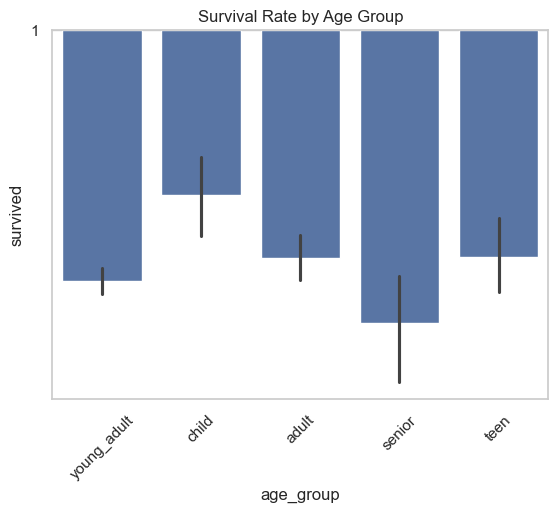

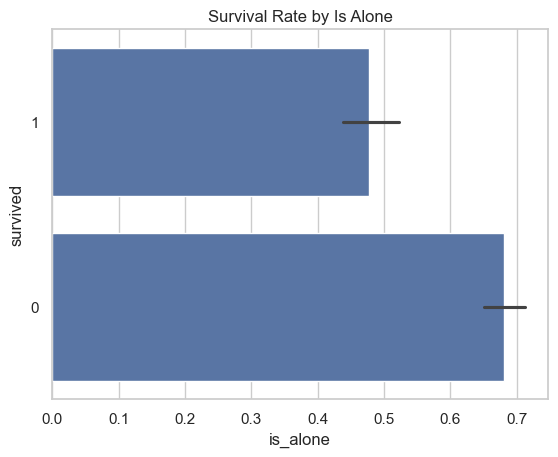

In [9]:
# Visualize engineered features vs target

if target_col in titanic_fe.columns:
    sns.barplot(data=titanic_fe, x="age_group", y=target_col)
    plt.title("Survival Rate by Age Group")
    plt.xticks(rotation=45)
    plt.show()

    sns.barplot(data=titanic_fe, x="is_alone", y=target_col)
    plt.title("Survival Rate by Is Alone")
    plt.show()

### Encode Data for Feature Selection

Most feature selection methods require numeric input, so we one-hot encode categorical variables.

In [ ]:
# One-hot encode categorical variables

titanic_model = titanic_fe.copy()

# Drop leaky and identifier columns before encoding
# body = corpse ID number (only exists for deceased), boat = lifeboat number (only exists for survivors)
leak_and_id_cols = ["name", "ticket", "cabin", "boat", "body", "home.dest"]
titanic_model = titanic_model.drop(
    columns=[c for c in leak_and_id_cols if c in titanic_model.columns]
)

# Exclude target column from categorical encoding
cat_cols = [
    col for col in titanic_model.select_dtypes(
        include=["object", "str", "category", "bool"]
    ).columns.tolist()
    if col != target_col
]

print("Categorical columns to encode:")
print(cat_cols)

titanic_model = pd.get_dummies(
    titanic_model,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Create X and y
X = titanic_model.drop(columns=[target_col])
y = titanic_model[target_col].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

In [20]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Variance Threshold

Variance threshold removes columns with little or no variation.

Example: a column that is almost always 0 does not help much.

In [21]:
selector = VarianceThreshold(threshold=0.01)

X_train_var = selector.fit_transform(X_train)
selected_var_cols = X_train.columns[selector.get_support()]

print("Original features:", X_train.shape[1])
print("Features after variance threshold:", len(selected_var_cols))

display(pd.DataFrame({"selected_features": selected_var_cols}).head(20))

Original features: 19
Features after variance threshold: 18


,selected_features
0,age
1,sibsp
2,parch
3,fare
4,body
5,family_size
6,is_alone
7,fare_per_person
8,fare_log
9,pclass_2


### Correlation Filtering

Highly correlated features can be redundant.

This is especially useful for linear models.

sex_male                -0.517007
fare_log                 0.306298
pclass_3                -0.268090
fare                     0.247439
is_alone                -0.228771
fare_per_person          0.208189
embarked_s              -0.157836
age_group_child          0.120951
parch                    0.104100
age_group_young_adult   -0.073265
age                     -0.060929
age_group_senior        -0.053516
family_size              0.046585
pclass_2                 0.043186
body                    -0.039948
embarked_q              -0.035315
sibsp                   -0.016929
age_group_teen           0.015351
embarked_missing              NaN
Name: survived, dtype: float64

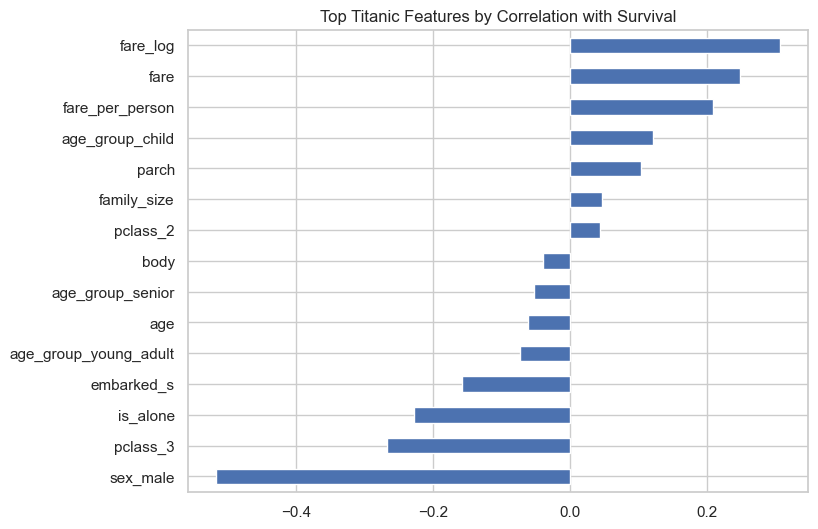

In [22]:
# Correlation with target

corr_df = X_train.copy()
corr_df[target_col] = y_train

target_corr = corr_df.corr(numeric_only=True)[target_col].drop(target_col)
target_corr = target_corr.sort_values(key=abs, ascending=False)

display(target_corr.head(20))

plt.figure(figsize=(8, 6))
target_corr.head(15).sort_values().plot(kind="barh")
plt.title("Top Titanic Features by Correlation with Survival")
plt.show()

In [23]:
# Remove highly correlated features

def remove_highly_correlated_features(df, threshold=0.90):
    corr_matrix = df.corr(numeric_only=True).abs()
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    cols_to_drop = [
        column for column in upper_triangle.columns
        if any(upper_triangle[column] > threshold)
    ]
    
    return cols_to_drop

high_corr_cols = remove_highly_correlated_features(X_train, threshold=0.90)

print("Highly correlated columns to drop:")
print(high_corr_cols)

X_train_corr_filtered = X_train.drop(columns=high_corr_cols)
X_test_corr_filtered = X_test.drop(columns=high_corr_cols)

print("Shape after correlation filtering:", X_train_corr_filtered.shape)

Highly correlated columns to drop:
[]
Shape after correlation filtering: (1047, 19)


### K-Best Feature Selection

K-Best selects the top K features based on statistical relationship with the target.

For classification, we can use:

- chi2 for non-negative features
- mutual information for general numeric features

,feature,score
11,sex_male,0.130275
8,fare_log,0.114781
3,fare,0.112282
7,fare_per_person,0.103344
5,family_size,0.066302
10,pclass_3,0.046852
4,body,0.042113
1,sibsp,0.039696
6,is_alone,0.024886
18,age_group_young_adult,0.022580


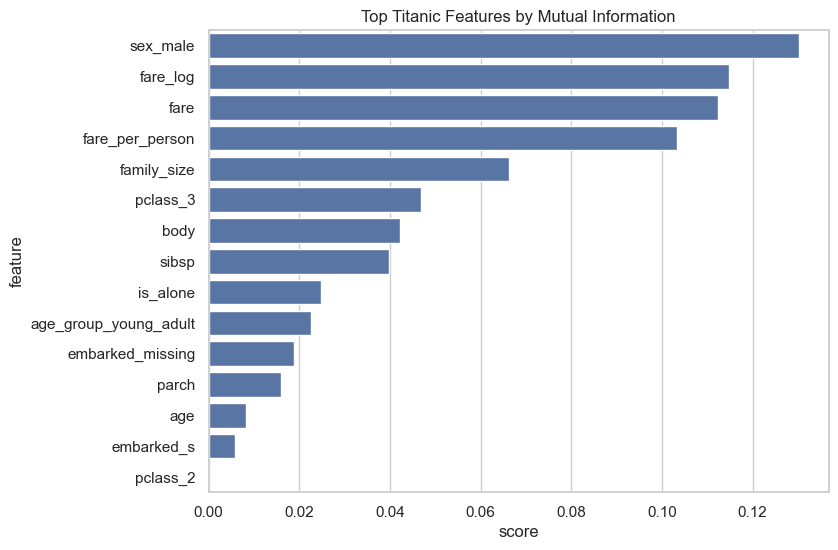

In [24]:
# Mutual information K-Best

k = min(10, X_train.shape[1])

kbest = SelectKBest(score_func=mutual_info_classif, k=k)
kbest.fit(X_train, y_train)

kbest_scores = pd.DataFrame({
    "feature": X_train.columns,
    "score": kbest.scores_
}).sort_values("score", ascending=False)

display(kbest_scores.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=kbest_scores.head(15), x="score", y="feature")
plt.title("Top Titanic Features by Mutual Information")
plt.show()

### Recursive Feature Elimination

RFE repeatedly trains a model and removes the weakest features.

Here we use Logistic Regression.

In [25]:
# Scale data for logistic regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, solver="liblinear")

rfe = RFE(
    estimator=log_reg,
    n_features_to_select=min(10, X_train.shape[1])
)

rfe.fit(X_train_scaled, y_train)

rfe_features = X_train.columns[rfe.support_]

print("Selected features by RFE:")
print(rfe_features.tolist())

Selected features by RFE:
['age', 'sibsp', 'family_size', 'is_alone', 'pclass_2', 'pclass_3', 'sex_male', 'embarked_q', 'embarked_s', 'age_group_child']


### L1 Logistic Regression Feature Selection

L1 (Lasso) regularization applied to Logistic Regression can shrink some feature coefficients to zero.

Features with non-zero coefficients are selected.

This is the correct approach for classification — `LassoCV` is a regression estimator and should not be used on binary targets.

In [ ]:
lasso_lr = LogisticRegressionCV(
    penalty="l1",
    solver="liblinear",
    cv=5,
    random_state=42,
    max_iter=5000,
    Cs=10
)

lasso_lr.fit(X_train_scaled, y_train)

lasso_importance = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lasso_lr.coef_[0]
})

lasso_selected = lasso_importance[lasso_importance["coefficient"] != 0]
lasso_selected = lasso_selected.sort_values("coefficient", key=abs, ascending=False)

print("Number of selected features:", lasso_selected.shape[0])
display(lasso_selected.head(20))

### Tree-Based Feature Importance

Tree models can rank features by how useful they are for splits.

This works well for non-linear relationships.

,feature,importance
11,sex_male,0.205995
0,age,0.191830
3,fare,0.123947
7,fare_per_person,0.123880
8,fare_log,0.123206
5,family_size,0.037125
4,body,0.032535
10,pclass_3,0.026948
1,sibsp,0.024097
14,embarked_s,0.019353


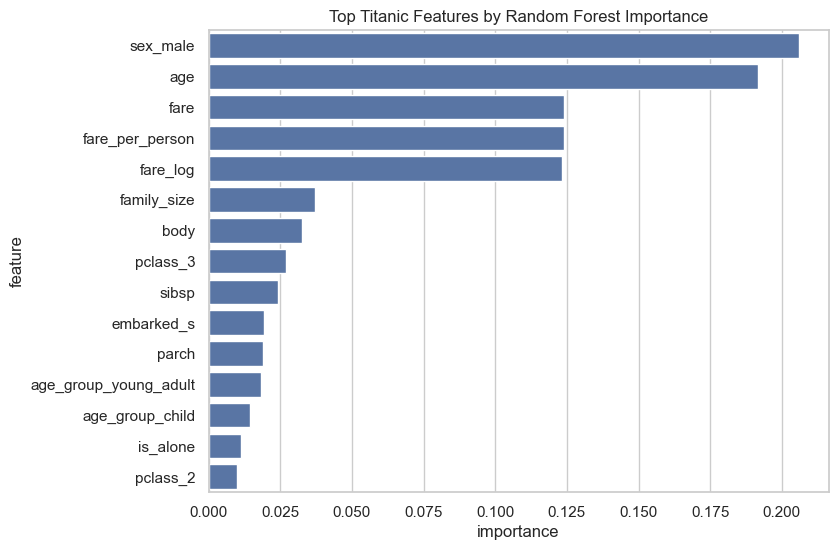

In [27]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importance.head(15), x="importance", y="feature")
plt.title("Top Titanic Features by Random Forest Importance")
plt.show()

### PCA

PCA creates new features called principal components.

It reduces dimensionality but reduces interpretability.

Original number of features: 19
Number of PCA components explaining 95% variance: 12


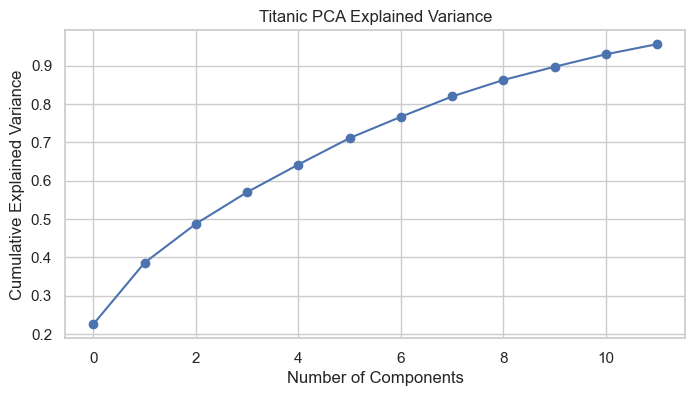

In [28]:
pca_scaler = StandardScaler()
X_train_pca_scaled = pca_scaler.fit_transform(X_train)
X_test_pca_scaled = pca_scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_pca_scaled)
X_test_pca = pca.transform(X_test_pca_scaled)

print("Original number of features:", X_train.shape[1])
print("Number of PCA components explaining 95% variance:", X_train_pca.shape[1])

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Titanic PCA Explained Variance")
plt.show()

## Titanic Section 4 Summary

For Titanic:

- Leaky columns (body, boat) and identifier columns (name, ticket, cabin, home.dest) are dropped before feature selection.
- Useful engineered features include family_size, is_alone, fare_per_person, fare_log, and age_group.
- Correlation and K-Best are easy first-pass feature selection methods.
- RFE and L1 Logistic Regression are useful for logistic/linear models.
- Random Forest feature importance captures non-linear relationships.
- PCA can reduce dimensionality but makes features harder to interpret.

## Feature Selection and Feature Engineering: LendingClub

For LendingClub, the target is:

- `not_fully_paid = 0`: loan was fully paid
- `not_fully_paid = 1`: loan was not fully paid

We will create features related to borrower risk, loan affordability, and credit behavior.

In [30]:
# Make working copy

lc_fe = lending_df.copy()

target_col = "not.fully.paid"

print("Shape:", lc_fe.shape)
print(lc_fe[target_col].value_counts())
display(lc_fe.head())

Shape: (9578, 14)
not.fully.paid
0    8045
1    1533
Name: count, dtype: int64


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


### Basic Preprocessing

We clean categorical columns, fill missing values, and prepare the data.

In [ ]:
# Clean categorical columns

cat_cols = lc_fe.select_dtypes(include=["object", "str", "category", "bool"]).columns.tolist()

for col in cat_cols:
    lc_fe[col] = lc_fe[col].astype("object")
    lc_fe[col] = lc_fe[col].fillna("missing")
    lc_fe[col] = lc_fe[col].astype(str).str.strip().str.lower()

# Impute numeric columns
num_cols = lc_fe.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col != target_col]

num_imputer = SimpleImputer(strategy="median")
lc_fe[num_cols] = num_imputer.fit_transform(lc_fe[num_cols])

print("Remaining missing values:", lc_fe.isnull().sum().sum())

### Feature Engineering

Possible LendingClub feature engineering:

- Installment-to-income ratio
- Loan-to-income ratio
- Credit history length
- Log annual income
- Log revolving balance
- Interest rate bins
- FICO average score
- FICO range width

In [ ]:
# Installment-to-income ratio
# log.annual.inc is already log of income — exponentiate to recover income estimate
if {"installment", "log.annual.inc"}.issubset(lc_fe.columns):
    lc_fe["installment_to_income"] = lc_fe["installment"] / np.exp(lc_fe["log.annual.inc"])

# FICO bins
if "fico" in lc_fe.columns:
    lc_fe["fico_bin"] = pd.cut(
        lc_fe["fico"],
        bins=[580, 620, 660, 700, 740, 850],
        labels=["poor", "fair", "good", "very_good", "exceptional"]
    ).astype("object").fillna("missing")

# Log transforms for skewed financial variables
for col, safe_name in [("revol.bal", "revol_bal_log"), ("installment", "installment_log")]:
    if col in lc_fe.columns:
        lc_fe[safe_name] = np.log1p(lc_fe[col])

# Interest rate bins
if "int.rate" in lc_fe.columns:
    lc_fe["int_rate_bin"] = pd.cut(
        lc_fe["int.rate"],
        bins=5,
        labels=["very_low", "low", "medium", "high", "very_high"]
    ).astype("object")

display(lc_fe.head())

In [ ]:
# Show engineered columns that were created

engineered_cols = [
    col for col in lc_fe.columns
    if col in [
        "installment_to_income",
        "fico_bin",
        "revol_bal_log",
        "installment_log",
        "int_rate_bin"
    ]
]

display(lc_fe[engineered_cols].head())

### Encode Data for Feature Selection

Feature selection methods require numeric inputs.

We one-hot encode categorical columns.

In [ ]:
lc_model = lc_fe.copy()

cat_cols = lc_model.select_dtypes(include=["object", "str", "category", "bool"]).columns.tolist()

lc_model = pd.get_dummies(
    lc_model,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

X = lc_model.drop(columns=[target_col])
y = lc_model[target_col].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

In [35]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Variance Threshold

Remove features with very low variation.

In [36]:
var_selector = VarianceThreshold(threshold=0.01)

X_train_var = var_selector.fit_transform(X_train)
selected_var_cols = X_train.columns[var_selector.get_support()]

print("Original features:", X_train.shape[1])
print("Features after variance threshold:", len(selected_var_cols))

display(pd.DataFrame({"selected_features": selected_var_cols}).head(30))

Original features: 19
Features after variance threshold: 18


,selected_features
0,credit.policy
1,installment
2,log.annual.inc
3,dti
4,fico
5,days.with.cr.line
6,revol.bal
7,revol.util
8,inq.last.6mths
9,delinq.2yrs


### Correlation Filtering

Remove redundant highly correlated variables.

This is useful before linear models.

int.rate                      0.159680
credit.policy                -0.159546
inq.last.6mths                0.148196
fico                         -0.145785
purpose_small_business        0.086056
revol.util                    0.083727
revol.bal                     0.057191
installment                   0.051150
purpose_credit_card          -0.047268
pub.rec                       0.046273
installment_log               0.043395
dti                           0.040064
purpose_major_purchase       -0.036482
log.annual.inc               -0.026892
days.with.cr.line            -0.016400
purpose_educational           0.014311
purpose_debt_consolidation   -0.013804
purpose_home_improvement      0.012261
delinq.2yrs                   0.012240
Name: not.fully.paid, dtype: float64

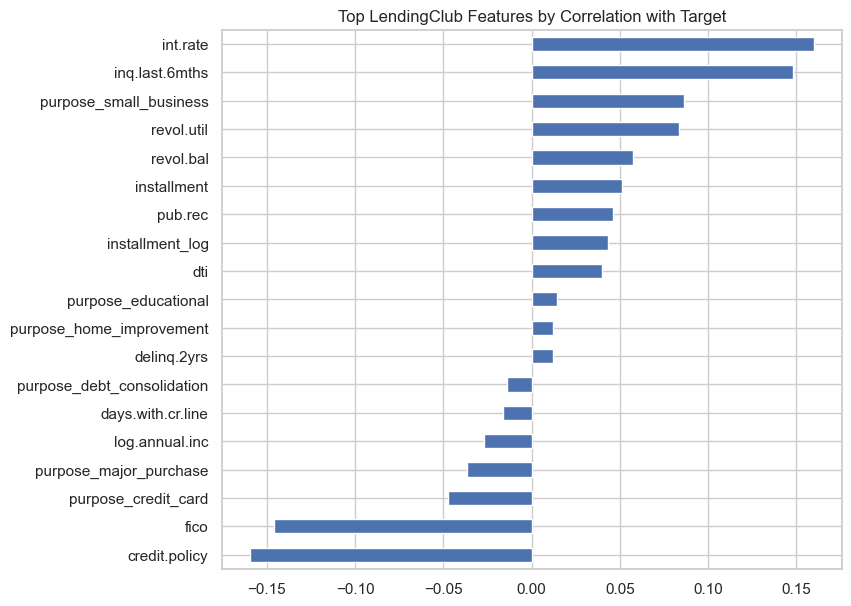

In [37]:
# Correlation with target

corr_df = X_train.copy()
corr_df[target_col] = y_train

target_corr = corr_df.corr(numeric_only=True)[target_col].drop(target_col)
target_corr = target_corr.sort_values(key=abs, ascending=False)

display(target_corr.head(25))

plt.figure(figsize=(8, 7))
target_corr.head(20).sort_values().plot(kind="barh")
plt.title("Top LendingClub Features by Correlation with Target")
plt.show()

In [38]:
# Remove highly correlated features

def remove_highly_correlated_features(df, threshold=0.90):
    corr_matrix = df.corr(numeric_only=True).abs()
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    cols_to_drop = [
        column for column in upper_triangle.columns
        if any(upper_triangle[column] > threshold)
    ]
    
    return cols_to_drop

high_corr_cols = remove_highly_correlated_features(X_train, threshold=0.90)

print("Number of highly correlated columns to drop:", len(high_corr_cols))
print(high_corr_cols[:30])

X_train_corr_filtered = X_train.drop(columns=high_corr_cols)
X_test_corr_filtered = X_test.drop(columns=high_corr_cols)

print("Shape after correlation filtering:", X_train_corr_filtered.shape)

Number of highly correlated columns to drop: 1
['installment_log']
Shape after correlation filtering: (7662, 18)


### K-Best Feature Selection

K-Best selects the top K features based on relationship with the target.

Here we use mutual information because it can capture non-linear relationships.

,feature,score
9,inq.last.6mths,0.015658
0,credit.policy,0.008877
1,int.rate,0.008472
8,revol.util,0.007434
5,fico,0.007157
18,purpose_small_business,0.006633
2,installment,0.004297
4,dti,0.004060
12,installment_log,0.003936
13,purpose_credit_card,0.002638


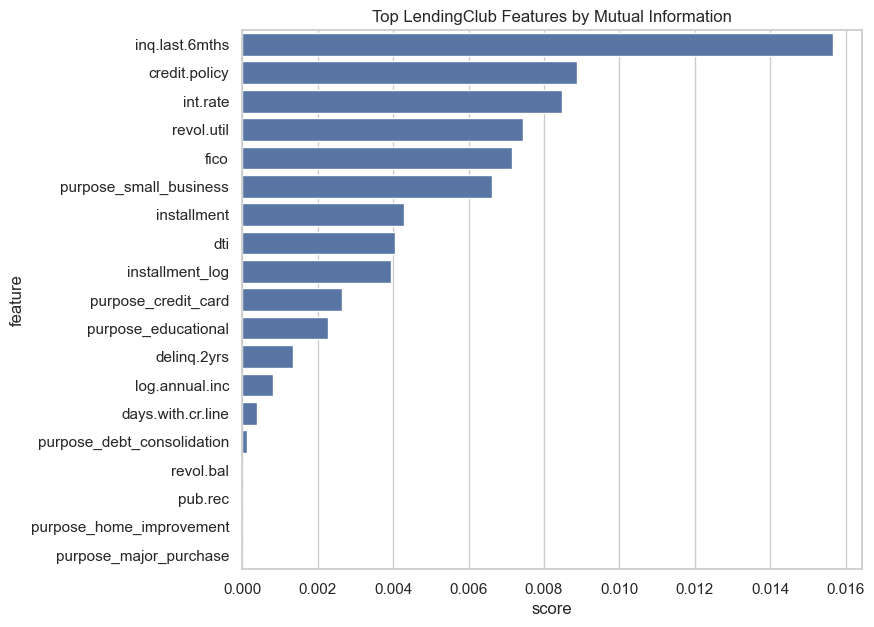

In [39]:
k = min(20, X_train.shape[1])

kbest = SelectKBest(score_func=mutual_info_classif, k=k)
kbest.fit(X_train, y_train)

kbest_scores = pd.DataFrame({
    "feature": X_train.columns,
    "score": kbest.scores_
}).sort_values("score", ascending=False)

display(kbest_scores.head(30))

plt.figure(figsize=(8, 7))
sns.barplot(data=kbest_scores.head(20), x="score", y="feature")
plt.title("Top LendingClub Features by Mutual Information")
plt.show()

### Recursive Feature Elimination

RFE trains a model repeatedly and removes weaker features.

For speed, we first use only the top features from variance filtering.

In [40]:
# Use variance-filtered data for faster RFE

X_train_rfe = pd.DataFrame(
    X_train_var,
    columns=selected_var_cols,
    index=X_train.index
)

# Limit to first 50 selected columns for speed if dataset is wide
rfe_candidate_cols = selected_var_cols[:min(50, len(selected_var_cols))]

X_train_rfe_small = X_train[rfe_candidate_cols]

scaler = StandardScaler()
X_train_rfe_scaled = scaler.fit_transform(X_train_rfe_small)

log_reg = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    class_weight="balanced"
)

rfe = RFE(
    estimator=log_reg,
    n_features_to_select=min(15, X_train_rfe_small.shape[1])
)

rfe.fit(X_train_rfe_scaled, y_train)

rfe_features = X_train_rfe_small.columns[rfe.support_]

print("Selected features by RFE:")
print(rfe_features.tolist())

Selected features by RFE:
['credit.policy', 'installment', 'log.annual.inc', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'installment_log', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_major_purchase', 'purpose_small_business']


### L1 Logistic Regression Feature Selection

L1 (Lasso) regularization can shrink less useful feature coefficients to zero.

This is the correct approach for classification — `LassoCV` is a regression estimator and should not be used on binary targets.

In [ ]:
# Scale data for L1 Logistic Regression

lasso_candidate_cols = selected_var_cols[:min(100, len(selected_var_cols))]

X_train_lasso = X_train[lasso_candidate_cols]

scaler = StandardScaler()
X_train_lasso_scaled = scaler.fit_transform(X_train_lasso)

lasso_lr = LogisticRegressionCV(
    penalty="l1",
    solver="liblinear",
    cv=5,
    random_state=42,
    max_iter=5000,
    Cs=10
)

lasso_lr.fit(X_train_lasso_scaled, y_train)

lasso_importance = pd.DataFrame({
    "feature": X_train_lasso.columns,
    "coefficient": lasso_lr.coef_[0]
})

lasso_selected = lasso_importance[lasso_importance["coefficient"] != 0]
lasso_selected = lasso_selected.sort_values("coefficient", key=abs, ascending=False)

print("Number of selected features:", lasso_selected.shape[0])
display(lasso_selected.head(30))

### Tree-Based Feature Importance

Random Forest can capture non-linear relationships and interactions.

,feature,importance
1,int.rate,0.108340
6,days.with.cr.line,0.100760
8,revol.util,0.099430
3,log.annual.inc,0.098985
7,revol.bal,0.097865
4,dti,0.096502
2,installment,0.090345
12,installment_log,0.088297
5,fico,0.078891
9,inq.last.6mths,0.050760


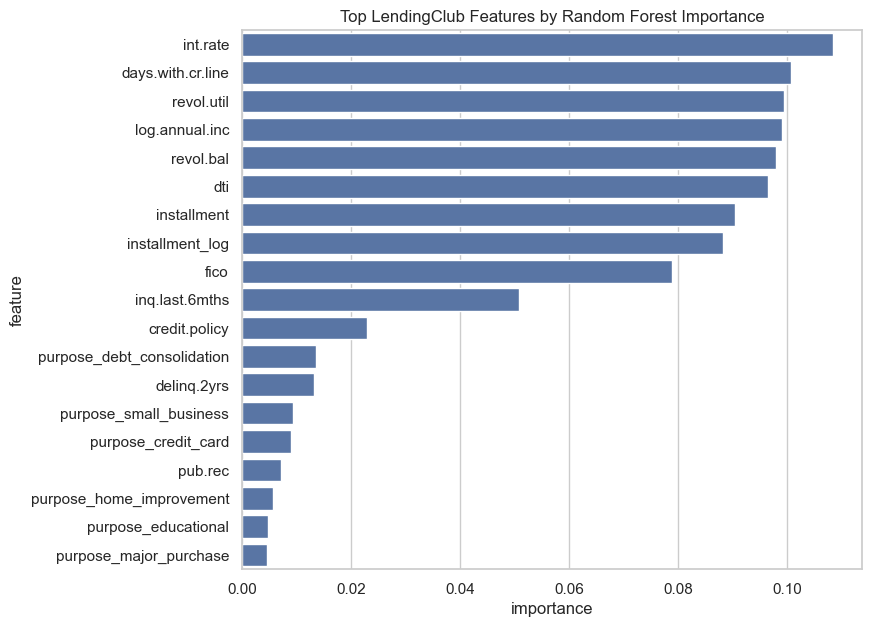

In [42]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance.head(30))

plt.figure(figsize=(8, 7))
sns.barplot(data=rf_importance.head(20), x="importance", y="feature")
plt.title("Top LendingClub Features by Random Forest Importance")
plt.show()

### PCA

PCA reduces dimensionality by creating new components.

It is useful when there are many correlated numeric features, but the new features are harder to interpret.

Original number of PCA input features: 18
Number of PCA components explaining 95% variance: 15


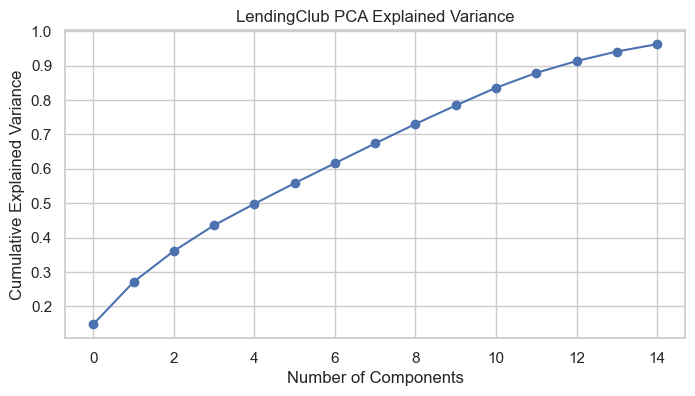

In [43]:
# Use a manageable number of features for PCA

pca_cols = selected_var_cols[:min(100, len(selected_var_cols))]

X_train_pca_input = X_train[pca_cols]
X_test_pca_input = X_test[pca_cols]

pca_scaler = StandardScaler()
X_train_pca_scaled = pca_scaler.fit_transform(X_train_pca_input)
X_test_pca_scaled = pca_scaler.transform(X_test_pca_input)

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_pca_scaled)
X_test_pca = pca.transform(X_test_pca_scaled)

print("Original number of PCA input features:", X_train_pca_input.shape[1])
print("Number of PCA components explaining 95% variance:", X_train_pca.shape[1])

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("LendingClub PCA Explained Variance")
plt.show()

## LendingClub Section 4 Summary

For LendingClub:

- Useful engineered features include installment_to_income, revol_bal_log, installment_log, fico_bin, and int_rate_bin.
- Variance threshold removes low-information features.
- Correlation filtering removes redundant features (e.g., installment_log is highly correlated with installment).
- K-Best is useful for quick feature ranking.
- RFE and L1 Logistic Regression are useful for logistic/linear models.
- Random Forest feature importance captures non-linear patterns.
- PCA can reduce dimensionality but reduces interpretability.